In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
client_df = pd.read_csv(r"C:\Users\eichi\OneDrive\Documents\Data_analysis\Pandas\client_data.csv")
price_df = pd.read_csv(r"C:\Users\eichi\OneDrive\Documents\Data_analysis\Pandas\price_data.csv")

print("Client Data Info: ")
print(client_df.info())

print("\nPrice Data Info: ")
price_df.info()

Client Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_mete

In [5]:
date_cols = ["date_activ", "date_end", "date_modif_prod", "date_renewal"]

for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors = 'coerce')
    missing = client_df[col].isnull().sum()
    print(f"Column {col} missing value after conversion: {missing}")

Column date_activ missing value after conversion: 0
Column date_end missing value after conversion: 0
Column date_modif_prod missing value after conversion: 0
Column date_renewal missing value after conversion: 0


In [6]:
missing_counts = client_df.isnull().sum()
print("\nMissing values per column in client data:")
print(missing_counts[missing_counts > 0])


Missing values per column in client data:
Series([], dtype: int64)


In [7]:
print("\nDescriptive statistics for numeric columns:")
client_df.describe()


Descriptive statistics for numeric columns:


,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,...,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912448,2016-07-27 20:48:26.422018560,2013-01-02 12:29:10.951663872,2015-07-21 06:59:00.353279488,1868.614880,1399.762906,0.966726,...,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,...,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,...,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,...,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,...,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000
std,5.734653e+05,1.629731e+05,64364.196422,NaN,NaN,NaN,NaN,2387.571531,3247.786255,5.108289,...,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175


In [8]:
cat_cols = ['channel_sales', 'has_gas', 'origin_up', 'churn']

for col in cat_cols:
    print(f"\nUnique value counts for {col}:")
    print(client_df[col].value_counts(dropna=False))


Unique value counts for channel_sales:
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

Unique value counts for has_gas:
has_gas
f    11955
t     2651
Name: count, dtype: int64

Unique value counts for origin_up:
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64

Unique value counts for churn:
churn
0    13187
1     1419
Name: count, dtype: int64


In [9]:
duplicates = client_df.duplicated().sum()
print(f"\nNumber of duplicate rows in client data: {duplicates}")


Number of duplicate rows in client data: 0


In [10]:
print("\nPreview Client data: ")
client_df.head()


Preview Client data: 


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


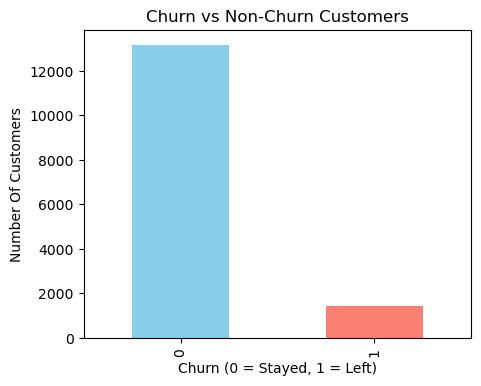

In [21]:
churn_counts = client_df['churn'].value_counts()

plt.figure(figsize = (5,4))
churn_counts.plot(kind = 'bar', color = ['skyblue','salmon'])
plt.title('Churn vs Non-Churn Customers')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Number Of Customers')
plt.show()

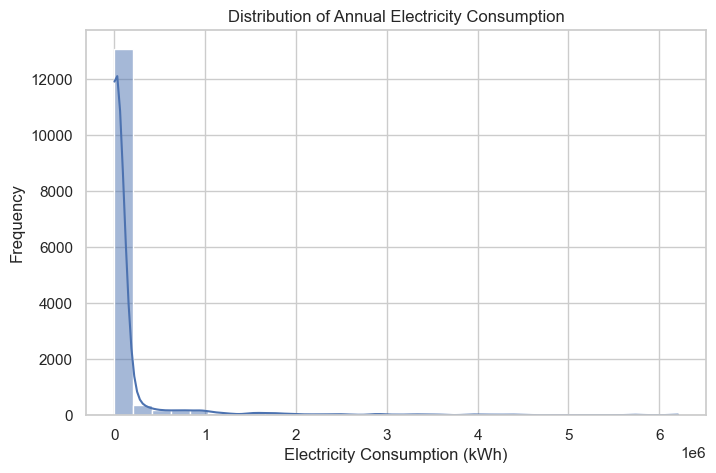

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(client_df['cons_12m'], bins=30, kde=True)
plt.title('Distribution of Annual Electricity Consumption')
plt.xlabel('Electricity Consumption (kWh)')
plt.ylabel('Frequency')
plt.show()

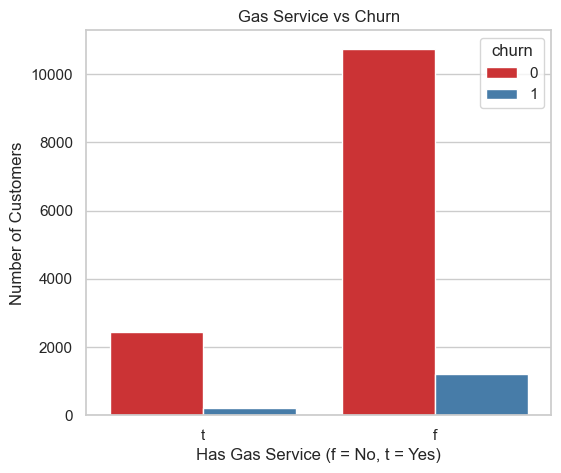

In [69]:
plt.figure(figsize=(6,5))
sns.countplot(x='has_gas', hue='churn', data=client_df, palette='Set1')
plt.title('Gas Service vs Churn')
plt.xlabel('Has Gas Service (f = No, t = Yes)')
plt.ylabel('Number of Customers')
plt.show()


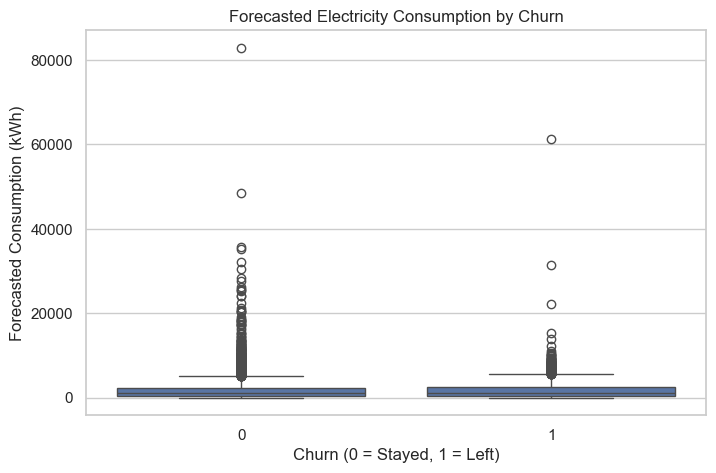

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='forecast_cons_12m', data=client_df)
plt.title('Forecasted Electricity Consumption by Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Forecasted Consumption (kWh)')
plt.show()
